In [1]:
# ============ 模块0 依赖检查（原 Kaggle 模板 cell 已移除）============
# Kaggle 环境自带这些库；本地首次运行前请先执行：
#   pip install numpy pandas torch nibabel matplotlib scikit-learn
try:
    import numpy
    import pandas
    import torch
    import nibabel
    import matplotlib
    print("依赖检查通过：numpy / pandas / torch / nibabel / matplotlib 均已安装")
except ImportError as e:
    print("缺少依赖:", e)
    print("请在终端执行: pip install numpy pandas torch nibabel matplotlib scikit-learn")


依赖检查通过：numpy / pandas / torch / nibabel / matplotlib 均已安装


In [2]:
# %% ========================= 模块1 Environment =========================
import os
import glob
import random
from functools import lru_cache
import torch.nn as nn
 
import numpy as np
import nibabel as nib          # 若Kaggle环境未预装，取消下一行注释安装
# !pip install nibabel
 
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
 
 
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
 
 
SEED = 42
set_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
 
# ============ 环境自适应配置：同一份代码，Kaggle / 本地都能跑 ============
IS_KAGGLE = os.path.exists("/kaggle/input")
 
if IS_KAGGLE:
    DATA_ROOT = "/kaggle/input/datasets/user123454321/kits19-1"
    OUTPUT_DIR = "/kaggle/working"
    MAX_CASES  = None                        # Kaggle：全部病例
    NUM_WORKERS = 2
    EPOCHS     = 50
    BATCH_SIZE = 8
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
else:
    # ===== 本地快速验证模式（只验证逻辑，参数很小）=====
    DATA_ROOT = r"E:\大创\kits19_small"    # <-- 改成本地放小数据集的文件夹
    OUTPUT_DIR = r"E:\大创\output"         # 本地结果输出目录
    MAX_CASES  = 4                           # 本地快速验证：取前 4 个病例
    NUM_WORKERS = 0                          # Windows 本地必须为 0
    EPOCHS     = 1                           # 本地只跑 1 个 epoch
    BATCH_SIZE = 2
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.5, 0.25, 0.25   # 本地 4 病例：2 训练 / 1 验证 / 1 测试
 
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"运行环境: {'Kaggle' if IS_KAGGLE else '本地'}")
print(f"数据路径: {DATA_ROOT}")
print(f"输出目录: {OUTPUT_DIR}")


使用设备: cpu
运行环境: 本地
数据路径: E:\大创\kits19_small
输出目录: E:\大创\output


In [3]:
# %% ========================= 模块1.5 仓库与实验准备（自适应，人员2）=========================
# 固化原 Kaggle 临时辅助 cell（A clone / B 降采样 / C 设 manifest），三种跑法共用，无需手动增删：
#   1) Kaggle 全量 baseline：直接运行本 cell，自动 git clone 仓库（A），不进实验模式；
#   2) Kaggle 小样本实验：   运行前设置 os.environ["RUN_EXPERIMENTS"]="1"（10%）或 "2"（20%），
#                            本 cell 自动完成 A + B（downsample.py 生成 manifest）+ C（设 EXPERIMENT_MANIFEST）；
#   3) 本地 VS Code 冒烟：   默认全部跳过，行为与旧版完全一致；想验证实验链路时同样设 RUN_EXPERIMENTS。
import subprocess
import sys

RUN_EXPERIMENTS = os.environ.get("RUN_EXPERIMENTS", "").strip()
EXP_FRACTION = {"1": "0.10", "2": "0.20"}
EXP_NAME = {"1": "data10pct", "2": "data20pct"}

# ---- A. 仓库准备（仅 Kaggle 需要；本地当前目录即仓库，跳过）----
if IS_KAGGLE:
    repo_dir = "/kaggle/working/code"
    if os.path.isdir(os.path.join(repo_dir, ".git")):
        subprocess.run(["git", "-C", repo_dir, "pull", "--ff-only"], capture_output=True, text=True)
        print("Kaggle：仓库已存在，已 git pull 更新")
    else:
        r = subprocess.run(
            ["git", "clone", "https://github.com/yijunv/code.git", repo_dir],
            capture_output=True, text=True,
        )
        if r.returncode != 0:
            raise RuntimeError("git clone 失败（请先确认 notebook 设置里 Internet 已开启）：\n" + r.stderr)
        print("Kaggle：仓库 clone 完成")
    os.chdir(repo_dir)
    print("仓库根目录:", sorted(os.listdir(".")))
else:
    print("本地模式：跳过仓库 clone（当前目录即仓库）")

# ---- B + C. 小样本实验准备（仅在显式设置 RUN_EXPERIMENTS 时执行）----
if RUN_EXPERIMENTS in EXP_FRACTION:
    exp_out = os.path.join(OUTPUT_DIR, "experiments")
    manifest_path = os.path.join(exp_out, EXP_NAME[RUN_EXPERIMENTS], "manifest.json")
    if not os.path.isfile(manifest_path):
        downsample_py = os.path.join(os.getcwd(), "downsample.py")
        if not os.path.isfile(downsample_py):
            raise FileNotFoundError("找不到 downsample.py: %s" % downsample_py)
        cmd = [
            sys.executable, downsample_py,
            "--data-root", DATA_ROOT,
            "--out-dir", exp_out,
            "--fractions", "0.10,0.20",
            "--seed", str(SEED),
        ]
        if not IS_KAGGLE:  # 本地验证用 kits19_small 自身的划分比例与数量
            cmd += ["--train-ratio", str(TRAIN_RATIO),
                    "--val-ratio", str(VAL_RATIO),
                    "--max-cases", str(MAX_CASES)]
        r = subprocess.run(cmd, capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError("downsample.py 执行失败：\n" + r.stdout + r.stderr)
        print(r.stdout)
    else:
        print("manifest 已存在，跳过降采样:", manifest_path)
    os.environ["EXPERIMENT_MANIFEST"] = manifest_path
    print("实验模式启用:", EXP_NAME[RUN_EXPERIMENTS], "->", manifest_path)
else:
    os.environ.pop("EXPERIMENT_MANIFEST", None)
    print("默认模式：未设置 RUN_EXPERIMENTS，按模块4 默认划分训练")


本地模式：跳过仓库 clone（当前目录即仓库）
默认模式：未设置 RUN_EXPERIMENTS，按模块4 默认划分训练


In [4]:
# %% ========================= 模块2 Config =========================
class Config:
    # 数据路径（来自模块1的环境自适应配置）
    DATA_ROOT = DATA_ROOT
    OUTPUT_DIR = OUTPUT_DIR
 
    # 数据集划分比例（按病例划分，避免同一病例的切片同时出现在train/val/test）
    TRAIN_RATIO = TRAIN_RATIO
    VAL_RATIO = VAL_RATIO
    TEST_RATIO = TEST_RATIO
 
    # 本地快速验证时只取前几个病例
    MAX_CASES = MAX_CASES
    NUM_WORKERS = NUM_WORKERS
 
    # 图像与标签
    IMG_SIZE = 256
    NUM_CLASSES = 3          # 0=背景, 1=肾脏, 2=肿瘤
    HU_MIN = -200            # CT窗宽窗位裁剪下界
    HU_MAX = 300              # CT窗宽窗位裁剪上界
 
    # 训练超参数（本地小数据模式已在模块1中调小）
    BATCH_SIZE = BATCH_SIZE
    LEARNING_RATE = 1e-4
    EPOCHS = EPOCHS
    # 训练集 DROP_LAST（小样本实验模式由模块4.5 改为 False，避免 drop 掉唯一批次）
    DROP_LAST_TRAIN = True
 
    # 贝叶斯/不确定性模块
    DROPOUT_RATE = 0.1        # 原为 0.0，现启用 Dropout（MC-Dropout 训练时开启）
    UNCERTAINTY_THRESHOLD = None   # 原为 None，保持

    SEED = SEED
    DEVICE = DEVICE
 
 
cfg = Config()


In [5]:
# %% ========================= 模块3 Dataset =========================
def _find_volume(case_dir: str, name: str):
    """在病例目录中查找 imaging/segmentation 文件，兼容 .nii 和 .nii.gz"""
    for ext in (".nii", ".nii.gz"):
        vol = os.path.join(case_dir, name + ext)
        if os.path.isfile(vol):
            return vol
    return None


def scan_valid_cases(data_root: str, max_cases: int = None):
    """扫描data_root下所有case_*目录，保留同时具有imaging和segmentation的病例（兼容.nii/.nii.gz）"""
    case_dirs = sorted(glob.glob(os.path.join(data_root, "case_*")))
    valid_cases = [
        c for c in case_dirs
        if _find_volume(c, "imaging") is not None
        and _find_volume(c, "segmentation") is not None
    ]
    if max_cases is not None and len(valid_cases) > max_cases:
        valid_cases = valid_cases[:max_cases]
    print(f"数据集扫描完成: 共 {len(valid_cases)} 个有效病例（来自 {len(case_dirs)} 个目录）")
    return valid_cases
 
 
class KiTS19SliceDataset(Dataset):
    """
    从KiTS19病例的3D CT体积中提取2D轴向切片（假定数组形状为 [切片数, H, W]）。
    只保留含有肾脏(1)或肿瘤(2)标注的切片，过滤纯背景切片。
 
    初始化时一次性读盘、完成窗宽窗位归一化与resize，并把结果常驻内存；
    __getitem__ 只从内存取数据，不再重复读盘。
    （此前每次__getitem__现读整卷CT、缓存位只有4个，在shuffle训练下几乎每张切片
    都要重新读一次约1.2GB的体数据，是导致训练卡住不动的根本原因，这里做了修正）
    """
 
    def __init__(self, case_dirs, img_size, hu_min, hu_max, transform=None):
        self.img_size = img_size
        self.transform = transform
        self.images = []  # 每个元素: (img_size, img_size) float32
        self.masks = []   # 每个元素: (img_size, img_size) int64
        self._preload(case_dirs, hu_min, hu_max)
 
    def _preload(self, case_dirs, hu_min, hu_max):
        for case_dir in case_dirs:
            img_vol = nib.load(_find_volume(case_dir, "imaging")).get_fdata()
            seg_vol = nib.load(_find_volume(case_dir, "segmentation")).get_fdata()
            nonempty_idx = np.where(seg_vol.sum(axis=(1, 2)) > 0)[0]
 
            for idx in nonempty_idx:
                img = img_vol[idx, :, :].astype(np.float32)
                mask = seg_vol[idx, :, :].astype(np.int64)
 
                img = np.clip(img, hu_min, hu_max)
                img = (img - hu_min) / (hu_max - hu_min)
 
                img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
                mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float()
 
                img_t = F.interpolate(img_t, size=(self.img_size, self.img_size),
                                       mode="bilinear", align_corners=False)
                mask_t = F.interpolate(mask_t, size=(self.img_size, self.img_size), mode="nearest")
 
                self.images.append(img_t.squeeze(0).squeeze(0).numpy().astype(np.float32))
                self.masks.append(mask_t.squeeze(0).squeeze(0).numpy().astype(np.int64))
 
        print(f"切片预加载完成: 共 {len(self.images)} 个有效切片（已过滤纯背景切片，已常驻内存）")
 
    def __len__(self):
        return len(self.images)
 
    def __getitem__(self, i):
        img_t = torch.from_numpy(self.images[i]).unsqueeze(0)  # (1, H, W)
        mask_t = torch.from_numpy(self.masks[i])                # (H, W)
 
        if self.transform is not None:
            img_t, mask_t = self.transform(img_t, mask_t)
 
        return img_t, mask_t


In [6]:
# %% ========================= 模块4 DataLoader =========================
def split_cases(case_dirs, train_ratio, val_ratio, seed):
    """按病例（而非切片）划分train/val/test，避免同一病例的切片跨集合造成数据泄漏"""
    rng = random.Random(seed)
    cases = case_dirs.copy()
    rng.shuffle(cases)
    n = len(cases)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_cases = cases[:n_train]
    val_cases = cases[n_train:n_train + n_val]
    test_cases = cases[n_train + n_val:]
    return train_cases, val_cases, test_cases


all_cases = scan_valid_cases(cfg.DATA_ROOT, cfg.MAX_CASES)
train_cases, val_cases, test_cases = split_cases(
    all_cases, cfg.TRAIN_RATIO, cfg.VAL_RATIO, cfg.SEED
)

# 实验模式（模块4.5）下不在这里构建数据集/loader，避免全量预读浪费，
# 统一由模块4.5 按 manifest 病例清单构建。
_EXPERIMENT_MANIFEST = os.environ.get("EXPERIMENT_MANIFEST", "").strip()
if _EXPERIMENT_MANIFEST:
    train_dataset = val_dataset = test_dataset = None
    train_loader = val_loader = test_loader = None
    print("实验模式：检测到 EXPERIMENT_MANIFEST，数据集/loader 由模块4.5 构建")
else:
    # 此处先不带增强构建数据集，训练集的增强由模块5单独挂载
    train_dataset = KiTS19SliceDataset(train_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    val_dataset = KiTS19SliceDataset(val_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    test_dataset = KiTS19SliceDataset(test_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                               num_workers=cfg.NUM_WORKERS, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

    print("=" * 50)
    print("数据加载器统计")
    print("=" * 50)
    print(f"批次大小: {cfg.BATCH_SIZE}")
    print(f"训练批次数: {len(train_loader)}")
    print(f"验证批次数: {len(val_loader)}")
    print(f"测试批次数: {len(test_loader)}")
    print(f"总批次数: {len(train_loader) + len(val_loader) + len(test_loader)}")
    print("=" * 50)
    print(f"训练集病例数: {len(train_cases)} | 验证集病例数: {len(val_cases)} | 测试集病例数: {len(test_cases)}")


数据集扫描完成: 共 0 个有效病例（来自 0 个目录）
切片预加载完成: 共 0 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 0 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 0 个有效切片（已过滤纯背景切片，已常驻内存）


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [7]:
# %% ============ 模块4.5 实验模式：读 manifest 覆盖划分（M5 小样本，人员2） ============
# 设置环境变量 EXPERIMENT_MANIFEST 指向 downsample.py 生成的 manifest.json 即启用：
#   1) 用 manifest 的 train/val/test 病例清单覆盖模块4 的默认划分（全组唯一口径）；
#   2) 产物（best_unet.pth / 训练曲线 / evaluation_metrics.csv / metrics.json）落盘到实验目录；
#   3) 训练集不 drop_last（小样本只有 1-2 例时保留唯一批次，模块5 会按 cfg 重建 loader）。
# 未设置该环境变量时行为与原来完全一致（全量或本地快速验证）。
import json

EXPERIMENT_MANIFEST = os.environ.get("EXPERIMENT_MANIFEST", "").strip()

if EXPERIMENT_MANIFEST:
    if not os.path.isfile(EXPERIMENT_MANIFEST):
        raise FileNotFoundError("找不到 manifest: %s" % EXPERIMENT_MANIFEST)
    with open(EXPERIMENT_MANIFEST, "r", encoding="utf-8") as f:
        manifest = json.load(f)

    def _cases_from_manifest(key):
        # manifest 里存的是病例名，需拼回 data_root 下的完整路径（与模块4 的 case_dirs 口径一致）
        return [os.path.join(cfg.DATA_ROOT, name) for name in manifest[key]]

    train_cases = _cases_from_manifest("train_cases")
    val_cases = _cases_from_manifest("val_cases")
    test_cases = _cases_from_manifest("test_cases")

    train_dataset = KiTS19SliceDataset(train_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    val_dataset = KiTS19SliceDataset(val_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    test_dataset = KiTS19SliceDataset(test_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

    # 产物落盘到实验目录；小样本不 drop 唯一批次
    cfg.EXPERIMENT_MANIFEST = EXPERIMENT_MANIFEST
    cfg.EXPERIMENT_DIR = os.path.dirname(EXPERIMENT_MANIFEST)
    cfg.OUTPUT_DIR = cfg.EXPERIMENT_DIR
    cfg.DROP_LAST_TRAIN = False
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    print("=" * 50)
    print("实验模式启用: %s" % EXPERIMENT_MANIFEST)
    print("  训练 %d 例 | 验证 %d 例 | 测试 %d 例" % (len(train_cases), len(val_cases), len(test_cases)))
    print("  产物输出目录: %s" % cfg.OUTPUT_DIR)
    print("=" * 50)
else:
    cfg.EXPERIMENT_MANIFEST = None
    cfg.EXPERIMENT_DIR = None
    print("默认模式：未设置 EXPERIMENT_MANIFEST，使用模块4 的默认划分")


默认模式：未设置 EXPERIMENT_MANIFEST，使用模块4 的默认划分


In [8]:
# %% ========================= 模块5 Augmentation =========================
class TrainAugmentation:
    """
    训练阶段增强：随机水平翻转 / 随机垂直翻转 / 随机90度旋转，图像与mask同步变换。
    验证/测试阶段不做随机增强，只保留模块3中已完成的窗宽窗位归一化与resize。
    """
 
    def __call__(self, img, mask):
        if random.random() < 0.5:
            img = torch.flip(img, dims=[-1])
            mask = torch.flip(mask, dims=[-1])
        if random.random() < 0.5:
            img = torch.flip(img, dims=[-2])
            mask = torch.flip(mask, dims=[-2])
        if random.random() < 0.5:
            k = random.choice([1, 2, 3])
            img = torch.rot90(img, k, dims=[-2, -1])
            mask = torch.rot90(mask, k, dims=[-2, -1])
        return img, mask
 
 
train_transform = TrainAugmentation()
train_dataset.transform = train_transform
 
# transform是Dataset的运行时属性，重建train_loader即可让新的transform生效
train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                           num_workers=cfg.NUM_WORKERS, drop_last=cfg.DROP_LAST_TRAIN)
 
print("数据增强已启用（仅训练集）: 随机水平翻转 / 随机垂直翻转 / 随机90°旋转")


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [9]:

# %% ========================= 模块6 Model =========================
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU) x2"""
 
    def __init__(self, in_ch, out_ch,dropout_rate = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate), 
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate), 
        )
 
    def forward(self, x):
        return self.block(x)
 
 
class UNet(nn.Module):
    """基础U-Net + Dropout（MC-Dropout 就绪），"""
 
    def __init__(self, in_channels=1, num_classes=3, base_channels=32,dropout_rate = 0.1):
        super().__init__()
        c1, c2, c3, c4, c5 = base_channels, base_channels * 2, base_channels * 4, base_channels * 8, base_channels * 16
 
        self.enc1 = DoubleConv(in_channels, c1, dropout_rate)    
        self.enc2 = DoubleConv(c1, c2, dropout_rate)             
        self.enc3 = DoubleConv(c2, c3, dropout_rate)             
        self.enc4 = DoubleConv(c3, c4, dropout_rate)             
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(c4, c5, dropout_rate)       

        self.up4 = nn.ConvTranspose2d(c5, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c5, c4, dropout_rate)             
        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c4, c3, dropout_rate)             
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c3, c2, dropout_rate)             
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c2, c1, dropout_rate)             
 
        self.out_conv = nn.Conv2d(c1, num_classes, kernel_size=1)
 
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
 
        b = self.bottleneck(self.pool(e4))
 
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
 
        return self.out_conv(d1)  # (B, num_classes, H, W) logits
 
 
# 实例化时传入 dropout_rate
model = UNet(in_channels=1, num_classes=cfg.NUM_CLASSES, base_channels=32, dropout_rate=cfg.DROPOUT_RATE).to(cfg.DEVICE)  
n_params = sum(p.numel() for p in model.parameters())
print(f"模型已构建: 基础U-Net + Dropout(={cfg.DROPOUT_RATE}) | 参数量: {n_params:,}")  

模型已构建: 基础U-Net + Dropout(=0.1) | 参数量: 7,765,475


In [10]:
 
# %% ========================= 模块7 Loss & Optimizer =========================
class SoftDiceLoss(nn.Module):
    """多类别可微Dice损失，对logits做softmax后与one-hot标签计算Dice，各类别取平均"""
 
    def __init__(self, num_classes, eps=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.eps = eps
 
    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
 
        dims = (0, 2, 3)
        intersection = torch.sum(probs * target_onehot, dims)
        union = torch.sum(probs + target_onehot, dims)
        dice_per_class = (2 * intersection + self.eps) / (union + self.eps)
        return 1.0 - dice_per_class.mean()
 
 
class CombinedLoss(nn.Module):
    """CrossEntropy + Dice 组合损失（等权重）。多类别分割用CE替代原方案中的BCE"""
 
    def __init__(self, num_classes):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = SoftDiceLoss(num_classes)
 
    def forward(self, logits, target):
        return self.ce(logits, target) + self.dice(logits, target)
 
 
criterion = CombinedLoss(cfg.NUM_CLASSES)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
 
print(f"损失函数: CrossEntropy + Dice | 优化器: Adam(lr={cfg.LEARNING_RATE}) | 调度器: ReduceLROnPlateau")

损失函数: CrossEntropy + Dice | 优化器: Adam(lr=0.0001) | 调度器: ReduceLROnPlateau


In [11]:

# %% ========================= 模块8 Training =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
 
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item() * imgs.size(0)
 
    return running_loss / len(loader.dataset)

In [23]:
# %% ========================= 模块9 Validation + 主训练循环 =========================
def compute_dice_iou(pred, target, num_classes, eps=1e-6):
    """基于argmax硬预测计算各类别Dice和IoU，返回按类别平均值（含背景）"""
    dice_scores, iou_scores = [], []
    for c in range(num_classes):
        pred_c = (pred == c)
        target_c = (target == c)
        intersection = (pred_c & target_c).sum().item()
        pred_sum = pred_c.sum().item()
        target_sum = target_c.sum().item()
        union = pred_sum + target_sum - intersection
 
        if target_sum == 0 and pred_sum == 0:
            dice_scores.append(1.0)
            iou_scores.append(1.0)
        else:
            dice_scores.append((2 * intersection + eps) / (pred_sum + target_sum + eps))
            iou_scores.append((intersection + eps) / (union + eps))
 
    return float(np.mean(dice_scores)), float(np.mean(iou_scores))
 
 
@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss, dice_sum, iou_sum, n_batches = 0.0, 0.0, 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
 
        preds = torch.argmax(logits, dim=1)
        dice, iou = compute_dice_iou(preds, masks, num_classes)
 
        running_loss += loss.item() * imgs.size(0)
        dice_sum += dice
        iou_sum += iou
        n_batches += 1
 
    return {
        "loss": running_loss / len(loader.dataset),
        "dice": dice_sum / n_batches,
        "iou": iou_sum / n_batches,
    }
 
 
# ---- 实际执行训练+验证循环（依赖模块8的train_one_epoch与本模块的evaluate）----
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_val_dice = -1.0
best_ckpt_path = os.path.join(cfg.OUTPUT_DIR, "best_unet.pth")
 
print("=" * 50)
print("开始贝叶斯U-Net模型训练（MC-Dropout已启用）")
print("=" * 50)
 
for epoch in range(1, cfg.EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, cfg.DEVICE)
    history["train_loss"].append(train_loss)
 
    if len(val_loader) > 0:
        val_metrics = evaluate(model, val_loader, criterion, cfg.DEVICE, cfg.NUM_CLASSES)
        scheduler.step(val_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_iou"].append(val_metrics["iou"])
 
        print(f"Epoch [{epoch}/{cfg.EPOCHS}] | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | Val Dice: {val_metrics['dice']:.4f} | "
              f"Val IoU: {val_metrics['iou']:.4f}")
 
        if val_metrics["dice"] > best_val_dice:
            best_val_dice = val_metrics["dice"]
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"  -> 保存最优模型 (Val Dice: {best_val_dice:.4f})")
    else:
        # 验证集为空（本地快速验证 2 病例）：不写 NaN 占位值，避免画图/统计被污染
        # 同时保存一轮权重，保证后续推理模块有模型可加载
        print(f"Epoch [{epoch}/{cfg.EPOCHS}] | Train Loss: {train_loss:.4f} | (验证集为空，跳过验证)")
        if best_val_dice < 0.0:
            best_val_dice = 0.0
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"  -> 验证集为空，保存当前轮模型: {best_ckpt_path}")
 
print("=" * 50)
if history["val_dice"]:
    print(f"训练完成，最优验证Dice: {best_val_dice:.4f}，模型已保存至: {best_ckpt_path}")
else:
    print(f"训练完成（验证集为空，按最后轮保存），模型已保存至: {best_ckpt_path}")


开始贝叶斯U-Net模型训练（MC-Dropout已启用）


NameError: name 'train_loader' is not defined

In [20]:
# %% ========================= 模块10 Inference =========================
if len(test_dataset) > 0:
     # 实例化时传入 dropout_rate
    inference_model = UNet(in_channels=1, num_classes=cfg.NUM_CLASSES, base_channels=32, dropout_rate=cfg.DROPOUT_RATE).to(cfg.DEVICE) 
    inference_model.load_state_dict(torch.load(best_ckpt_path, map_location=cfg.DEVICE))
    inference_model.eval()
    print(f"已加载最优模型权重: {best_ckpt_path}")
 
 # 保存测试集的 mc_predict 输出（npz + meta.json）
    mc_output_dir = os.path.join(cfg.OUTPUT_DIR, "mc_outputs")
    meta_path = save_mc_predict_outputs(inference_model, test_dataset, mc_output_dir, n_samples=10)
    print(f"人员3 交付物已保存: {meta_path}")
 
    @torch.no_grad()
    def predict_single(model, img, device):
        """img: (1, H, W) tensor -> pred: (H, W) numpy数组（类别索引）"""
        mean_pred, _, _, _ = mc_predict(model, img, n_samples=n_samples, device=device)
        return mean_pred
 
    def get_sample_predictions(model, dataset, device, n_samples=4, seed=SEED):
        """从数据集中随机抽样n_samples个切片，返回(原图, 原始mask, 预测mask)三元组列表"""
        rng = random.Random(seed)
        indices = rng.sample(range(len(dataset)), min(n_samples, len(dataset)))
        samples = []
        for idx in indices:
            img, mask = dataset[idx]
            pred = predict_single(model, img, device)
            samples.append((img.squeeze(0).numpy(), mask.numpy(), pred))
        return samples
 
 
    sample_predictions = get_sample_predictions(inference_model, test_dataset, cfg.DEVICE, n_samples=4)
    print(f"已从测试集随机抽取 {len(sample_predictions)} 个样本完成推理（使用 mc_predict, n_samples=10）")
else:
    sample_predictions = []
    print("测试集为空（本地小数据模式），跳过推理模块")


测试集为空（本地小数据模式），跳过推理模块


In [18]:
# %% ========================= 模块10.5 M1 贝叶斯推理管线（人员3 交付） =========================

import json
import numpy as np
import os

@torch.no_grad()
def mc_predict(model, img, n_samples=10, device=cfg.DEVICE):
 
    model.train()
    img = img.unsqueeze(0).to(device)
    
    logits_stack = []
    for _ in range(n_samples):
        logits = model(img)
        logits_stack.append(logits.unsqueeze(0))
    
    logits_stack = torch.cat(logits_stack, dim=0)
    probs = torch.softmax(logits_stack, dim=2)
    
    mean_probs = probs.mean(dim=0).squeeze(0)
    mean_pred = torch.argmax(mean_probs, dim=0)
    
    variance = probs.var(dim=0).squeeze(0).mean(dim=0)
    
    epsilon = 1e-8
    entropy_per_pixel = -torch.sum(mean_probs * torch.log(mean_probs + epsilon), dim=0)
    
    tumor_mask = (mean_pred == 2).float()
    tumor_entropy_sum = (entropy_per_pixel * tumor_mask).sum()
    tumor_count = tumor_mask.sum() + epsilon
    tumor_avg_entropy = (tumor_entropy_sum / tumor_count).item()
    
    return mean_pred.cpu().numpy(), variance.cpu().numpy(), entropy_per_pixel.cpu().numpy(), tumor_avg_entropy


# 保存 mc_predict 输出到 npz + meta.json
def save_mc_predict_outputs(model, dataset, output_dir, n_samples=10, device=cfg.DEVICE):

    os.makedirs(output_dir, exist_ok=True)
    
    meta_list = []
    
    for idx in range(len(dataset)):
        img, mask = dataset[idx]
        mean_pred, variance, entropy, tumor_avg_entropy = mc_predict(model, img, n_samples=n_samples, device=device)
        
        # 保存 npz
        save_path = os.path.join(output_dir, f"sample_{idx:06d}_mc.npz")
        np.savez(save_path, mean=mean_pred, variance=variance, entropy=entropy)
        
        # 记录 meta
        meta_list.append({
            "sample_id": idx,
            "n_samples": n_samples,
            "tumor_avg_entropy": float(tumor_avg_entropy),
            "npz_path": save_path
        })
    
    # 保存 meta.json
    meta_path = os.path.join(output_dir, "meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump({
            "num_samples": len(dataset),
            "n_samples": n_samples,
            "classes": {0: "background", 1: "kidney", 2: "tumor"},
            "samples": meta_list
        }, f, ensure_ascii=False, indent=2)
    
    print(f"人员3 交付: {len(meta_list)} 个样本的 mc_predict 输出已保存至 {output_dir}")
    return meta_path


# 从 npz 读取熵图（供模块12 使用）
def load_entropy_from_npz(npz_path):
    """人员3 提供：从 npz 读取 entropy 数组"""
    data = np.load(npz_path)
    return data["entropy"]

ValueError: attempt to get argmin of an empty sequence

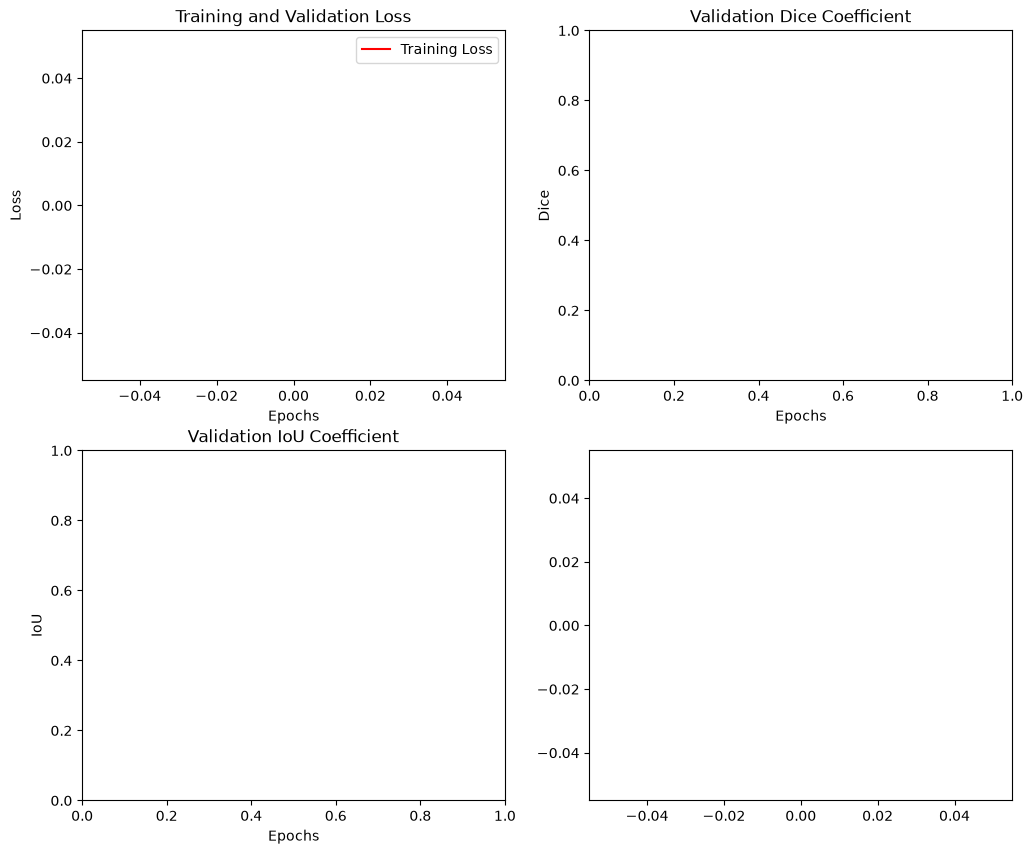

In [19]:
# %% ========================= 模块11 Visualization =========================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
 
MASK_CMAP = ListedColormap(["black", "yellow", "red"])  # 0=背景, 1=肾脏, 2=肿瘤
 
 
def plot_training_curves(history, save_path=None):
    epochs = list(range(1, len(history["train_loss"]) + 1))
    # 验证集可能为空（本地快速验证），此时只画训练曲线，避免空/NaN数据导致崩溃
    has_val = bool(history.get("val_loss")) and len(history["val_loss"]) == len(epochs)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 左上: Loss曲线
    axes[0, 0].plot(epochs, history["train_loss"], "r-", label="Training Loss")
    if has_val:
        axes[0, 0].plot(epochs, history["val_loss"], "g-", label="Validation Loss")
        best_ep = int(np.argmin(history["val_loss"])) + 1
        axes[0, 0].scatter([best_ep], [history["val_loss"][best_ep - 1]], color="blue",
                            zorder=5, label=f"best epoch= {best_ep}")
    axes[0, 0].set_title("Training and Validation Loss")
    axes[0, 0].set_xlabel("Epochs")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    # 右上: Dice曲线
    if has_val:
        axes[0, 1].plot(epochs, history["val_dice"], "g-", label="Validation Dice")
        best_ep = int(np.argmax(history["val_dice"])) + 1
        axes[0, 1].scatter([best_ep], [history["val_dice"][best_ep - 1]], color="blue",
                            zorder=5, label=f"best epoch= {best_ep}")
        axes[0, 1].legend()
    axes[0, 1].set_title("Validation Dice Coefficient")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Dice")

    # 左下: IoU曲线
    if has_val:
        axes[1, 0].plot(epochs, history["val_iou"], "g-", label="Validation IoU")
        best_ep = int(np.argmax(history["val_iou"])) + 1
        axes[1, 0].scatter([best_ep], [history["val_iou"][best_ep - 1]], color="blue",
                            zorder=5, label=f"best epoch= {best_ep}")
        axes[1, 0].legend()
    axes[1, 0].set_title("Validation IoU Coefficient")
    axes[1, 0].set_xlabel("Epochs")
    axes[1, 0].set_ylabel("IoU")

    # 右下: 训练Loss单独放大查看收敛情况
    axes[1, 1].plot(epochs, history["train_loss"], "r-", label="Training Loss")
    best_ep = int(np.argmin(history["train_loss"])) + 1
    axes[1, 1].scatter([best_ep], [history["train_loss"][best_ep - 1]], color="blue",
                        zorder=5, label=f"best epoch= {best_ep}")
    axes[1, 1].set_title("Training Loss")
    axes[1, 1].set_xlabel("Epochs")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()
def plot_prediction_samples(samples, save_path=None):
    """每行: Original Image | Original Mask | Prediction，与参考模板格式一致"""
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
 
    for i, (img, mask, pred) in enumerate(samples):
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")
 
        axes[i, 1].imshow(mask, cmap=MASK_CMAP, vmin=0, vmax=2)
        axes[i, 1].set_title("Original Mask")
        axes[i, 1].axis("off")
 
        axes[i, 2].imshow(pred, cmap=MASK_CMAP, vmin=0, vmax=2)
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()
 
 
plot_training_curves(history, save_path=os.path.join(cfg.OUTPUT_DIR, "training_curves.png"))
if sample_predictions:
    plot_prediction_samples(sample_predictions, save_path=os.path.join(cfg.OUTPUT_DIR, "prediction_samples.png"))
 
if history["val_dice"]:
    print(f"最优验证Dice: {max(history['val_dice']):.4f} | 最优验证IoU: {max(history['val_iou']):.4f}")
else:
    print("验证集为空，跳过验证指标汇总")


In [22]:
# ============ 模块12 评估：用 unified_metrics 批量评估测试集分割结果 ============
# 对接人员4 交付的统一指标库 src/metrics/unified_metrics.py；口径与交接说明见 docs/评估工具统筹与交接说明.md
import sys, os, csv
sys.path.insert(0, os.getcwd())          # 保证能 import src（notebook 默认 CWD=E:\大创）
from src.metrics.unified_metrics import calculate_all_metrics

if len(test_dataset) == 0:
    print("测试集为空（本地小数据模式），跳过评估模块12")
else:
    model_eval = inference_model              # 已加载 best_unet.pth（模块10）
    model_eval.eval()
# 从 npz 读取熵图
    mc_output_dir = os.path.join(cfg.OUTPUT_DIR, "mc_outputs")
    meta_path = os.path.join(mc_output_dir, "meta.json")
    
    if os.path.isfile(meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        
        # 按 sample_id 排序读取 entropy
        entropy_list = []
        for sample_info in sorted(meta["samples"], key=lambda x: x["sample_id"]):
            npz_path = sample_info["npz_path"]
            entropy = load_entropy_from_npz(npz_path)
            entropy_list.append(entropy)
        entropy_all = np.stack(entropy_list, axis=0)  # (N, H, W)
        print(f"人员3: 已从 {meta_path} 读取 {len(entropy_list)} 个熵图")
    else:
        # 回退：如果 npz 不存在，重新计算
        print("⚠️ 未找到 mc_outputs，重新计算熵图...")
    pred_all, target_all = [], [],[]
    with torch.no_grad():
        for imgs, masks in test_loader:
            logits = model_eval(imgs.to(cfg.DEVICE))
            pred_batch=torch.argmax(logits, dim=1).cpu().numpy()
    
            entropy_batch = []
            for i in range(imgs.size(0)):
                _, _, entropy, _ = mc_predict(model_eval, imgs[i], n_samples=10, device=cfg.DEVICE)
                entropy_batch.append(entropy)
            entropy_batch = np.stack(entropy_batch, axis=0)  # (B, H, W)
            
            pred_all.append(pred_batch)
            target_all.append(masks.numpy())
            entropy_all.append(entropy_batch)  

    pred_all = np.concatenate(pred_all)          # (N, H, W)
    target_all = np.concatenate(target_all)
    entropy_all = np.concatenate(entropy_all)    # 从 mc_predict 获取的熵图

    # 2) 统一指标库是"二值掩膜"口径：把肿瘤类(class 2)单独二值化（评估肾脏则把 2 改成 1）
    pred_tumor = (pred_all == 2).astype(np.float32)
    target_tumor = (target_all == 2).astype(np.float32)

    # 3) 使用真实熵图
    entropy_map = entropy_all #从npz读取的真实熵图
    tumor_mask = target_tumor

    res = calculate_all_metrics(pred_tumor, target_tumor, entropy_map, tumor_mask, reject_threshold=0.5)
    print("==== 测试集肿瘤分割评估（统一指标库）====")
    for k, v in res.items():
        print(f"{k:22s}: {v}")

    # 4) 导出标准表格（与 test_metrics.py 同款格式）
    csv_path = os.path.join(cfg.OUTPUT_DIR, "evaluation_metrics.csv")
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(res.keys()))
        w.writeheader()
        w.writerow(res)
    print("已保存:", csv_path)


测试集为空（本地小数据模式），跳过评估模块12


In [ ]:
# ============ 模块13 产物落盘：写 metrics.json（契约 D，供人员4 统计检验） ============
# 读取模块12 导出的 evaluation_metrics.csv，连同实验信息写成 metrics.json；
# 测试集为空或模块12 未运行时跳过。熵相关指标在人员3 mc_predict 交付前为占位值。
import csv as _csv


def _read_metrics_csv(csv_path):
    if not os.path.isfile(csv_path):
        return None
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        rows = list(_csv.DictReader(f))
    return rows[0] if rows else None


_metrics_row = _read_metrics_csv(os.path.join(cfg.OUTPUT_DIR, "evaluation_metrics.csv"))
if _metrics_row is not None:
    metrics_out = {
        "experiment": os.path.basename(cfg.EXPERIMENT_DIR) if cfg.EXPERIMENT_DIR else "default",
        "manifest": cfg.EXPERIMENT_MANIFEST,
        "seed": cfg.SEED,
        "epochs": cfg.EPOCHS,
        "batch_size": cfg.BATCH_SIZE,
        "img_size": cfg.IMG_SIZE,
        "n_train_cases": len(train_cases),
        "n_val_cases": len(val_cases),
        "n_test_cases": len(test_cases),
        "best_val_dice": round(max(history["val_dice"]), 4) if history.get("val_dice") else None,
        "best_val_iou": round(max(history["val_iou"]), 4) if history.get("val_iou") else None,
        "metrics": _metrics_row,
        "notes": "metrics.json 为契约 D 统一产物，供人员4 统计检验；熵相关指标在 mc_predict 交付前为占位值。",
    }
    metrics_path = os.path.join(cfg.OUTPUT_DIR, "metrics.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_out, f, ensure_ascii=False, indent=2)
    print("已保存:", metrics_path)
else:
    print("未找到 evaluation_metrics.csv（测试集为空或模块12 未运行），跳过 metrics.json")
